<a href="https://colab.research.google.com/github/Vishalization/optimisation_resNet50/blob/main/optimization_sgd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!pip install disarray

In [ ]:
#extract Dataset
import zipfile
import os

zip_path = "/content/drive/MyDrive/skin_split.rar"

extract_path = "/content/dataset"
os.makedirs(extract_path, exist_ok=True)

!unrar x "{zip_path}" "{extract_path}"

In [4]:
#Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

from tensorflow.keras.optimizers import Adam, AdamW, SGD

from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint
)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.utils.class_weight import compute_class_weight

In [5]:
#Fix random seed
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [6]:
#Dataset Paths
train_dir = "/content/dataset/skin_split/train"
test_dir = "/content/dataset/skin_split/test"

In [7]:
#Baseline Data Generator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [8]:
#Train Generator
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED
)

Found 6411 images belonging to 7 classes.


In [9]:
#Val Generator
val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)

Found 1599 images belonging to 7 classes.


In [10]:
#Test Generator
test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2005 images belonging to 7 classes.


In [11]:
#Class Weight
class_labels = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.3820915926179085), 1: np.float64(2.7837603126356925), 2: np.float64(1.3009334415584415), 3: np.float64(12.376447876447877), 4: np.float64(1.2863162118780096), 5: np.float64(0.2133870323525496), 6: np.float64(10.06436420722135)}


In [12]:
#Build  Model
from tensorflow.keras.applications import ResNet50

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.models import Model

from tensorflow.keras.regularizers import l2

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

# Fine-tune entire network
base_model.trainable = True

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(
    256,
    activation='relu',
    kernel_regularizer=l2(0.001)
)(x)

x = Dropout(0.5)(x)

output = Dense(
    7,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
# Custom Focal Loss

def focal_loss(gamma=2.0, alpha=0.25):

    def focal_loss_fixed(y_true, y_pred):

        epsilon = 1e-7

        y_pred = tf.clip_by_value(
            y_pred,
            epsilon,
            1.0 - epsilon
        )

        cross_entropy = -y_true * tf.math.log(y_pred)

        loss = alpha * tf.pow(
            1 - y_pred,
            gamma
        ) * cross_entropy

        return tf.reduce_mean(
            tf.reduce_sum(loss, axis=1)
        )

    return focal_loss_fixed

In [14]:
model.compile(

    optimizer=SGD(
        learning_rate=1e-3,
        momentum=0.9
    ),

    loss=focal_loss(
        gamma=2.0,
        alpha=0.25
    ),

    metrics=['accuracy']
)

In [15]:
#Callbacks

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1,
    min_lr=1e-7
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_scheduler_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [16]:
#Train Scheduler  Model

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[reduce_lr, early_stop, checkpoint]
)

Epoch 1/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.5399 - loss: 0.7169
Epoch 1: val_accuracy improved from None to 0.67042, saving model to best_scheduler_model.keras

Epoch 1: finished saving model to best_scheduler_model.keras
201/201 ━━━━━━━━━━━━━━━━━━━━ 159s 555ms/step - accuracy: 0.6188 - loss: 0.6515 - val_accuracy: 0.6704 - val_loss: 1.0051 - learning_rate: 0.0010
Epoch 2/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.7053 - loss: 0.5746
Epoch 2: val_accuracy did not improve from 0.67042
201/201 ━━━━━━━━━━━━━━━━━━━━ 84s 394ms/step - accuracy: 0.7217 - loss: 0.5667 - val_accuracy: 0.6704 - val_loss: 1.3032 - learning_rate: 0.0010
Epoch 3/15
201/201 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - accuracy: 0.7564 - loss: 0.5479
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_accuracy did not improve from 0.67042
201/201 ━━━━━━━━━━━━━━━━━━━━ 80s 398ms/step - accuracy: 0.7649 - loss: 0.5432 - val_accuracy: 0.6704 - val_los

In [17]:
df=pd.DataFrame(history.history)
df.to_csv('hist.csv')

<Axes: >

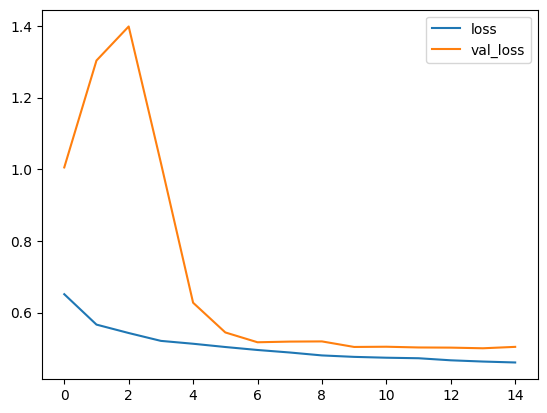

In [18]:
metrics = pd.DataFrame(history.history)
metrics[["loss","val_loss"]].plot()



<Axes: >

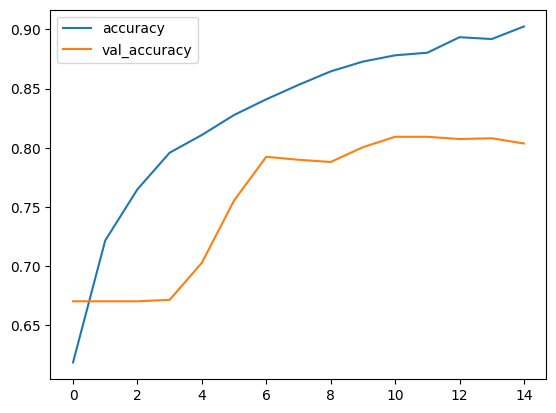

In [19]:
metrics[["accuracy","val_accuracy"]].plot()

In [20]:
model.evaluate(test_generator)

63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 347ms/step - accuracy: 0.8269 - loss: 0.4994


[0.49943745136260986, 0.8269326686859131]

In [21]:
predictions = model.predict(test_generator, verbose=1)
predictions = predictions.argmax(axis=1)

test_labels = test_generator.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 23s 302ms/step


In [22]:


import sklearn
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(test_labels, predictions)



Normalized confusion matrix


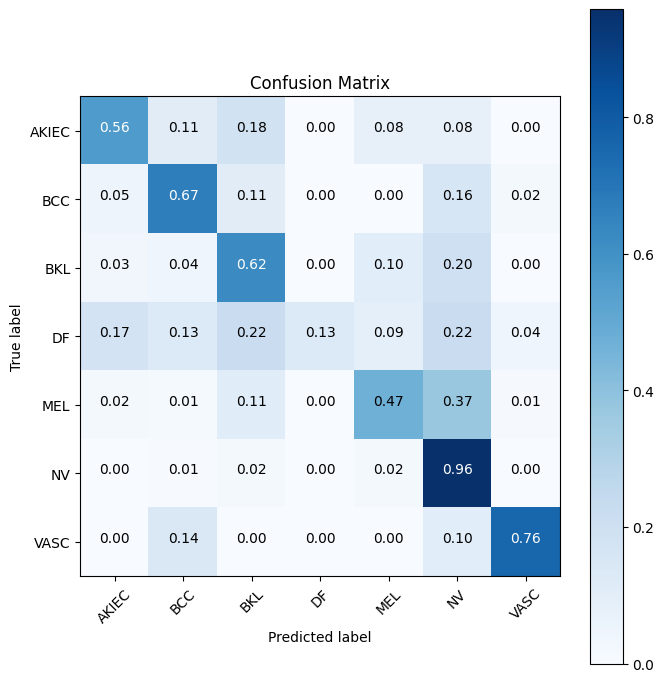

In [23]:
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
        print(cm)

    plt.figure(figsize=(7,7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


cm_plot_labels =['AKIEC','BCC','BKL','DF','MEL','NV','VASC']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix', normalize=True)

In [24]:
import disarray

df_cm = pd.DataFrame(
    cm,
    index=['AKIEC','BCC','BKL','DF','MEL','NV','VASC'],
    columns=['AKIEC','BCC','BKL','DF','MEL','NV','VASC']
)

metrics_focal = df_cm.da.export_metrics()

metrics_focal


,AKIEC,BCC,BKL,DF,MEL,NV,VASC,micro-average
accuracy,0.975062,0.965586,0.919202,0.990025,0.915711,0.894264,0.994015,0.950552
f1,0.596774,0.666667,0.628440,0.230769,0.554090,0.923796,0.785714,0.826933
false_discovery_rate,0.362069,0.336538,0.365741,0.000000,0.326923,0.108258,0.185185,0.173067
false_negative_rate,0.439394,0.330097,0.377273,0.869565,0.529148,0.041760,0.241379,0.173067
false_positive_rate,0.010830,0.018402,0.044258,0.000000,0.028620,0.234940,0.002530,0.028845
negative_predictive_value,0.985105,0.982115,0.953605,0.990010,0.936182,0.900709,0.996461,0.971155
positive_predictive_value,0.637931,0.663462,0.634259,1.000000,0.673077,0.891742,0.814815,0.826933
precision,0.637931,0.663462,0.634259,1.000000,0.673077,0.891742,0.814815,0.826933
recall,0.560606,0.669903,0.622727,0.130435,0.470852,0.958240,0.758621,0.826933
sensitivity,0.560606,0.669903,0.622727,0.130435,0.470852,0.958240,0.758621,0.826933


In [ ]:
metrics_focal.to_csv("focal_loss_metrics.csv")